In [5]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style='whitegrid', context='paper', font_scale=1.2,
    rc={
        'figure.figsize':(3.5,3.15), 
        'lines.linewidth':2.,
        'font.family': 'sans-serif',
        'font.sans-serif': [u'Helvetica'],
        'text.usetex': False,
})

In [15]:
path = Path("../results/")
df = pd.concat(map(pd.read_csv, path.rglob("results*.csv")), ignore_index=True)
df.columns

Index(['SIR', 'SIR_file', 'N_IMAGES_PERFORMANCE', 'nfft', 'VAD_GUARD',
       'bf_criterion', 'SDR_in', 'SIR_in', 'ref_mic_idx', 'SDR_out', 'SIR_out',
       'iSDR', 'iSIR', 'image_id', 'image_name', 'iwOIR_k', 'SP_k', 'SNR_k',
       'Rakeness_k', 'correlation_k', 'DI_k'],
      dtype='object')

In [14]:
df

,SIR,SIR_file,N_IMAGES_PERFORMANCE,nfft,VAD_GUARD,bf_criterion,SDR_in,SIR_in,ref_mic_idx,SDR_out,...,iSDR,iSIR,image_id,image_name,iwOIR_k,SP_k,SNR_k,Rakeness_k,correlation_k,DI_k
0,5,5,30,1024,1024,mvdr,-2.609985,7.859958,6,0.585463,...,3.195448,26.388910,0,0_direct,13.406542,1.004938,19.822128,0.383352,0.998021,0.108684
1,5,5,30,1024,1024,mvdr,-2.609985,7.859958,6,0.585463,...,3.195448,26.388910,1,1_north,9.709494,0.417379,16.006041,0.159217,0.146726,0.026960
2,5,5,30,1024,1024,mvdr,-2.609985,7.859958,6,0.585463,...,3.195448,26.388910,2,2_floor,8.512965,0.336393,15.069213,0.128323,0.555573,0.059318
3,5,5,30,1024,1024,mvdr,-2.609985,7.859958,6,0.585463,...,3.195448,26.388910,3,3_floor,5.877626,0.158916,11.812422,0.060622,0.095842,0.026527
4,5,5,30,1024,1024,mvdr,-2.609985,7.859958,6,0.585463,...,3.195448,26.388910,4,4_ceil,4.813578,0.115612,10.430777,0.044102,0.363125,0.025288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,5,5,30,1024,1024,lcmv,-2.609718,7.863962,22,0.314155,...,2.923874,20.162248,25,25_west,-3.564879,0.028364,0.932741,0.010678,0.011584,0.019375
116,5,5,30,1024,1024,lcmv,-2.609718,7.863962,22,0.314155,...,2.923874,20.162248,26,26_west,-6.093082,0.015511,-1.688435,0.005840,0.031743,0.015872
117,5,5,30,1024,1024,lcmv,-2.609718,7.863962,22,0.314155,...,2.923874,20.162248,27,27_west,-6.173865,0.015449,-1.705997,0.005816,0.014506,0.018953
118,5,5,30,1024,1024,lcmv,-2.609718,7.863962,22,0.314155,...,2.923874,20.162248,28,28_west,-8.747837,0.008458,-4.321979,0.003184,0.034105,0.015765


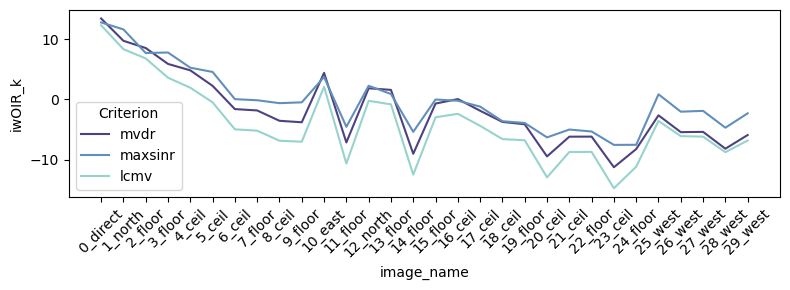

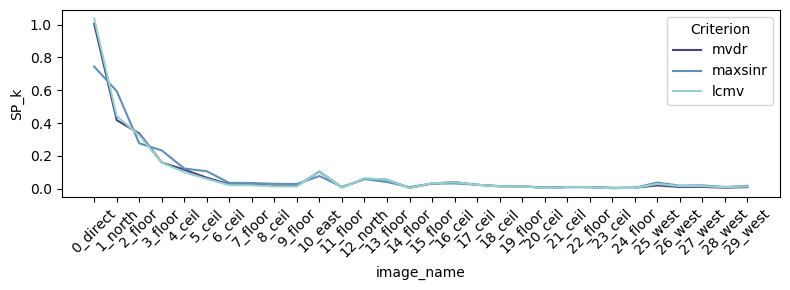

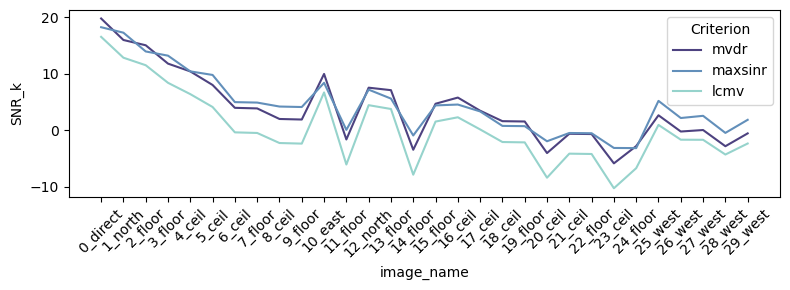

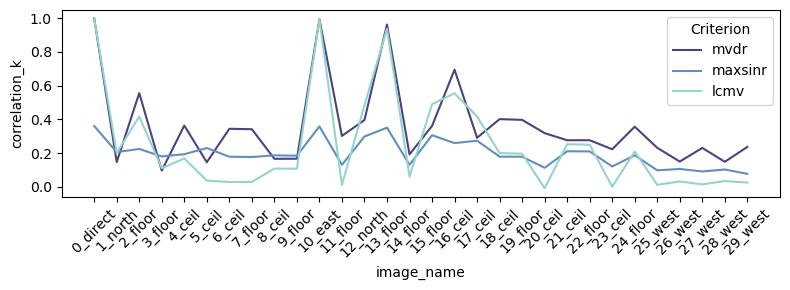

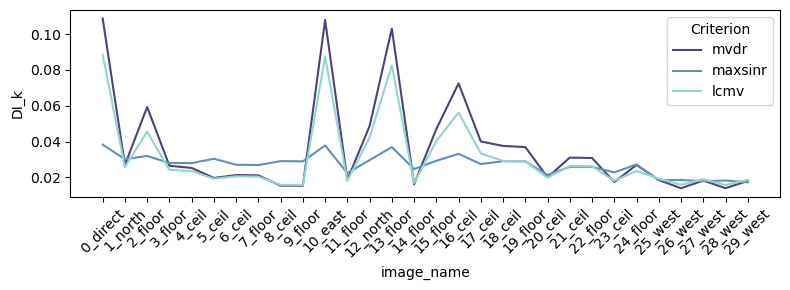

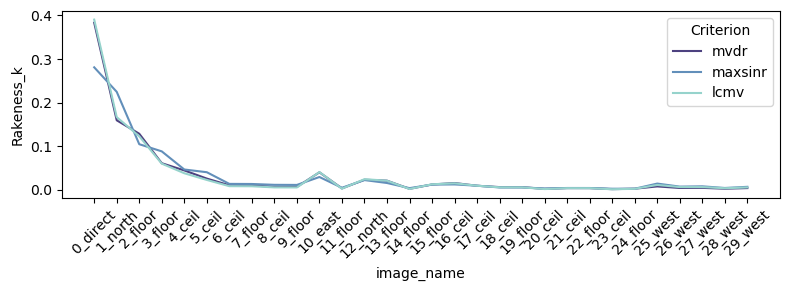

In [22]:
bf_criteria = df['bf_criterion'].unique()
n_bf = len(bf_criteria)
pal = sns.cubehelix_palette(n_bf, start=0.5, rot=-0.5,dark=0.3, light=.75, reverse=True, hue=1.)
sns.set_palette(pal)

for metric in ['iwOIR_k', 'SP_k', 'SNR_k', 'correlation_k', 'DI_k', 'Rakeness_k' ]:
    tmp_df = df[df['SIR'] == 5]
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.lineplot(x='image_name', y=metric, hue='bf_criterion', data=tmp_df, ax=ax)
    plt.xticks(rotation=45)
    plt.legend(title='Criterion')
    plt.tight_layout()
    plt.savefig(f'./fa2025_{metric}.pdf', dpi=300)
    plt.show()


In [23]:
sns.set(style='whitegrid', context='paper', font_scale=1.2,
        rc={
            'figure.figsize':(3.5,3.15), 
            'lines.linewidth':2.,
            'font.family': 'sans-serif',
            'font.sans-serif': [u'Helvetica'],
            'text.usetex': False,
            })
pal = sns.cubehelix_palette(n_masks, start=0.5, rot=-0.5,dark=0.3, light=.75, reverse=True, hue=1.)
sns.set_palette(pal)